In [1]:
import gym
import numpy as np
import torch
import torch.nn as nn

env = gym.make("CartPole-v1")

model = nn.Sequential(
    nn.Linear(4, 128),
    nn.ReLU(),
    nn.Linear(128, 2),
    nn.Softmax(dim=-1)   # 關鍵修正
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def discounted_returns(rewards, gamma=0.99):
    G = 0.0
    out = []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    out.reverse()
    out = torch.tensor(out, dtype=torch.float32)
    out = (out - out.mean()) / (out.std() + 1e-8)  # 穩定訓練
    return out




Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
MAX_EPISODES = 1000
MAX_DUR = 300
score = []

for ep in range(MAX_EPISODES):
    state, info = env.reset()
    traj = []  # (state, action, reward)

    for t in range(MAX_DUR):
        s = torch.from_numpy(state).float().unsqueeze(0)      # [1,4]
        probs = model(s).squeeze(0)                           # [2]
        action = np.random.choice([0, 1], p=probs.detach().numpy())

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        traj.append((state, action, reward))
        state = next_state
        if done:
            break

    score.append(len(traj))

    states = torch.tensor(np.array([x[0] for x in traj]), dtype=torch.float32)
    actions = torch.tensor([x[1] for x in traj], dtype=torch.long)
    rewards = [x[2] for x in traj]

    returns = discounted_returns(rewards, gamma=0.99)
    probs_all = model(states)  # [T,2]
    chosen_probs = probs_all.gather(1, actions.unsqueeze(1)).squeeze(1)

    loss = -(returns * torch.log(chosen_probs + 1e-8)).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

/Users/jim/anaconda3/envs/pytorch/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


In [3]:
# average
print(np.mean(score[-100:]))

273.57


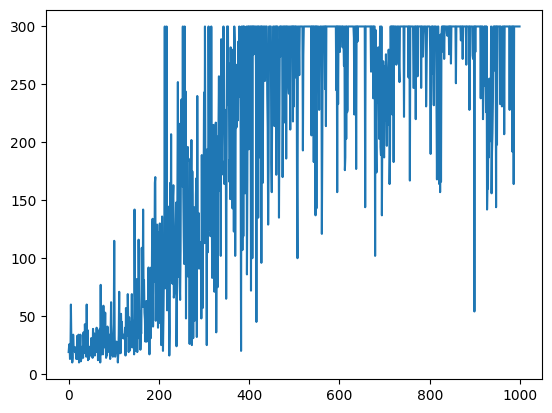

In [4]:
import matplotlib.pyplot as plt

plt.plot(score)